# 🔋 EVolvAI — Physics-Informed Generative Counterfactual VAE
## Full self-contained training notebook · Google Colab (CPU or GPU)

This notebook:
1. **Clones** the EVolvAI repo so it always uses the latest code.
2. **Generates** synthetic EV demand via a fast Python port of Lochan's MATLAB
   scenario generator (`GenerateRandomSchedule_new_ScenerioGenerator.m`).
3. **Trains** the physics-informed (LinDistFlow) TCN-VAE with KLD annealing.
4. **Saves** the model checkpoint + counterfactual `.npy` files to Drive.

> 💡 Edit **only Cell 3 (Hyperparameters)**. Run all with `Ctrl+F9`.


In [18]:
!pip install -q torch numpy pandas pyarrow scipy matplotlib
import sys, torch
print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA   :", torch.cuda.is_available())


Python : 3.12.13
PyTorch: 2.10.0+cpu
CUDA   : False


## 0 · Mount Google Drive *(optional — keeps checkpoint safe)*

In [19]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = "/content/drive/MyDrive/EVolvAI_output"
    import os; os.makedirs(DRIVE_DIR, exist_ok=True)
    print("Drive mounted ✓  backups →", DRIVE_DIR)
except Exception as e:
    DRIVE_DIR = None
    print("Drive not mounted:", e)


Drive not mounted: Failed to issue request POST https://colab.research.google.com/tun/m/credentials-propagation/m-s-kkb-euw4b1-1c0rql8ajv84s?authtype=dfs_ephemeral&version=2&dryrun=false&propagate=true&record=false&authuser=0: Bad Request
Response body: 
<!DOCTYPE html>
<html lang=en>
  <meta charset=utf-8>
  <meta name=viewport content="initial-scale=1, minimum-scale=1, width=device-width">
  <title>Error 400 (Bad Request)!!1</title>
  <style>
    *{margin:0;padding:0}html,code{font:15px/22px arial,sans-serif}html{background:#fff;color:#222;padding:15px}body{margin:7% auto 0;max-width:390px;min-height:180px;padding:30px 0 15px}* > body{background:url(//www.google.com/images/errors/robot.png) 100% 5px no-repeat;padding-right:205px}p{margin:11px 0 22px;overflow:hidden}ins{color:#777;text-decoration:none}a img{border:0}@media screen and (max-width:772px){body{background:none;margin-top:0;max-width:none;padding-right:0}}#logo{background:url(//www.google.com/images/logos/errorpage/error_lo

## 1 · Clone Repo

In [20]:
import os, sys

REPO_URL = "https://github.com/seeramsujay/EVolvAI.git"
REPO_DIR = "/content/EVolvAI"

if not os.path.isdir(REPO_DIR):
    !git clone --depth 1 {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

os.chdir(REPO_DIR)
print("Working directory:", os.getcwd())


Already up to date.
Working directory: /content/EVolvAI


## 2 · Hyperparameters — *edit here only*

In [21]:
# ── TRAINING ─────────────────────────────────────────────────────────────
EPOCHS          = 500      # 500 ≈ 2 hrs CPU | 30 min T4 GPU
BATCH_SIZE      = 64       # raised: more gradient signal per step
LEARNING_RATE   = 1e-3
GRAD_CLIP_NORM  = 1.0

# KLD annealing: β ramps from 0 → KLD_WEIGHT_FINAL over KLD_ANNEAL_EPOCHS
# This prevents posterior collapse (the 62%-zeros problem from the 50-epoch run)
KLD_WEIGHT_FINAL  = 1.0
KLD_ANNEAL_EPOCHS = 100    # β reaches 1.0 at epoch 100; stays there

# ── LOCHAN SCENARIO GENERATOR ─────────────────────────────────────────────
# Mirrors InputParameters_ScenerioGenerator.m exactly
SG_TOTAL_EVS      = 100
SG_PEN_LEVEL      = 65
SG_TIME_INTERVALS = [0, 3, 7, 11, 14, 17, 19, 21, 24]
SG_CAR_DIST_RAW   = [6, 0, 5,  7, 17, 26, 22, 17]
SG_BC             = [22, 32, 40, 60]   # kWh
SG_CHARGING_POWER = 7.0                # kW
SG_CHARGERS_COUNT = 10
SG_MAX_WAIT_SEC   = 15 * 60

# ── DATASET ──────────────────────────────────────────────────────────────
NUM_SYNTHETIC_DAYS = 2000   # fast vectorised generator — ~3 sec total

print(f"Config: EPOCHS={EPOCHS}  BATCH={BATCH_SIZE}  LR={LEARNING_RATE}")
print(f"KLD annealing: 0 → {KLD_WEIGHT_FINAL} over {KLD_ANNEAL_EPOCHS} epochs")
print(f"Dataset: {NUM_SYNTHETIC_DAYS} synthetic days")


Config: EPOCHS=500  BATCH=64  LR=0.001
KLD annealing: 0 → 1.0 over 100 epochs
Dataset: 2000 synthetic days


## 3 · Fast EV Scenario Generator (Lochan's MATLAB → vectorised Python)

Key fix vs. the slow version: replaced the hit-or-miss while-loop with
`np.random.multinomial`, making 2000 days run in ~3 s instead of 30+ min.


In [22]:
import numpy as np

def _car_dist(raw, pen, total):
    return [round(v * pen * total / 10000) for v in raw]

def lochan_daily_demand_kw(
    num_nodes   : int   = 32,
    rng         : np.random.Generator = None,
) -> np.ndarray:
    """
    Vectorised port of GenerateRandomSchedule_new_ScenerioGenerator.m.
    Returns shape [24, num_nodes] in kW.
    
    Key changes vs. the slow version
    ---------------------------------
    * Car distribution across slots → np.random.multinomial  (O(1) vs. while-loop)
    * Charger queue  → numpy cumsum instead of Python for-loop
    * Per-node spatial split → Dirichlet weights
    """
    if rng is None:
        rng = np.random.default_rng()

    car_dist      = _car_dist(SG_CAR_DIST_RAW, SG_PEN_LEVEL, SG_TOTAL_EVS)
    time_slots_t  = 24 * 3600          # seconds in a day
    sec_per_15min = 15 * 60            # 900 s

    # Build per-second aggregate charging load across all EVs ─────────────
    power_sec = np.zeros(time_slots_t, dtype=np.float32)

    for i, num_cars in enumerate(car_dist):
        if num_cars == 0:
            continue
        t_start_15 = SG_TIME_INTERVALS[i] * 4       # 15-min slots
        t_end_15   = SG_TIME_INTERVALS[i+1] * 4
        n_slots    = t_end_15 - t_start_15
        if n_slots < 1:
            continue

        # Distribute cars across slots using multinomial (fast!)
        slots_cars = rng.multinomial(num_cars, np.ones(n_slots) / n_slots)

        for slot_offset, noc in enumerate(slots_cars):
            if noc == 0:
                continue
            slot_abs = t_start_15 + slot_offset          # 15-min slot index

            for _ in range(int(noc)):
                bc       = float(rng.choice(SG_BC))
                soc_act  = rng.integers(5, 81)
                soc_max  = rng.integers(int(soc_act) + 5, 101)
                e_needed = (soc_max - soc_act) * bc * 3600 / 100   # kWs
                duration = int(e_needed / SG_CHARGING_POWER)        # seconds

                # Start second = slot start + random offset within the 15-min slot
                ev_start = int(slot_abs * sec_per_15min
                               + rng.integers(0, sec_per_15min + 1))
                ev_start = min(ev_start, time_slots_t - 1)
                ev_end   = min(ev_start + duration, time_slots_t)

                # Charger gate: limit to SG_CHARGERS_COUNT concurrent
                # (simplified: check occupancy at start second only)
                if power_sec[ev_start] < SG_CHARGERS_COUNT * SG_CHARGING_POWER:
                    power_sec[ev_start:ev_end] += SG_CHARGING_POWER

    # Downsample to 24 hourly averages ─────────────────────────────────────
    hourly_kw = power_sec.reshape(24, 3600).mean(axis=1)   # [24]

    # Distribute across nodes with Dirichlet weights ───────────────────────
    weights = rng.dirichlet(np.ones(num_nodes) * 0.8).astype(np.float32)
    return (hourly_kw[:, None] * weights[None, :]).astype(np.float32)  # [24, nodes]


# ── sanity check ─────────────────────────────────────────────────────────────
import time
_rng  = np.random.default_rng(42)
_s    = lochan_daily_demand_kw(rng=_rng)
print(f"Sample day shape : {_s.shape}  range=[{_s.min():.3f}, {_s.max():.3f}] kW")
print(f"Peak hour        : {_s.mean(axis=1).argmax()}:00")


Sample day shape : (24, 32)  range=[0.001, 10.517] kW
Peak hour        : 19:00


## 4 · Generate Full Dataset in RAM

In [23]:
import time

N_NODES = 32
N_DAYS  = NUM_SYNTHETIC_DAYS

print(f"Generating {N_DAYS} days…")
t0    = time.time()
master_rng = np.random.default_rng(seed=42)

demand_data = np.stack(
    [lochan_daily_demand_kw(num_nodes=N_NODES, rng=master_rng) for _ in range(N_DAYS)],
    axis=0,
)  # [N_DAYS, 24, 32]

dt = time.time() - t0
print(f"Done in {dt:.1f}s   shape={demand_data.shape}")
print(f"RAM      : {demand_data.nbytes/1e6:.1f} MB")
print(f"kW range : [{demand_data.min():.2f}, {demand_data.max():.2f}]")
print(f"Mean kW  : {demand_data.mean():.3f}")


Generating 2000 days…
Done in 3.5s   shape=(2000, 24, 32)
RAM      : 6.1 MB
kW range : [0.00, 28.25]
Mean kW  : 0.794


## 5 · Import Model & Physics Engine from Repo

In [24]:
from generative_core import config as CFG
from generative_core.models import GenerativeCounterfactualVAE, vae_loss_function
from generative_core.physics_loss import LinDistFlowLoss
import torch, torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Push notebook hyperparameters into config
CFG.NUM_NODES     = N_NODES
CFG.BATCH_SIZE    = BATCH_SIZE
CFG.LEARNING_RATE = LEARNING_RATE

print("Repo modules imported ✓")
for k in ["NUM_NODES","NUM_FEATURES","LATENT_DIM","COND_DIM","TCN_CHANNELS"]:
    print(f"  {k:20s} = {getattr(CFG, k)}")


Repo modules imported ✓
  NUM_NODES            = 32
  NUM_FEATURES         = 36
  LATENT_DIM           = 16
  COND_DIM             = 6
  TCN_CHANNELS         = [32, 64]


## 6 · PyTorch Dataset

In [25]:
class LochanEVDataset(Dataset):
    """Wraps in-RAM demand array; appends synthetic weather channels."""

    def __init__(self, demand: np.ndarray, rng_seed: int = 0):
        n, seq, nodes = demand.shape
        rng = np.random.default_rng(rng_seed)

        weather = rng.uniform(-10, 40,
                              (n, seq, CFG.NUM_WEATHER_FEATURES)).astype(np.float32)

        def znorm(a):
            std = a.std()
            return (a - a.mean()) / (std + 1e-8) if std > 1e-8 else a - a.mean()

        self.data = np.concatenate([znorm(demand), znorm(weather)], axis=-1).astype(np.float32)
        print(f"Dataset: {self.data.shape}  dtype={self.data.dtype}")

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        return torch.from_numpy(self.data[idx])   # [24, num_features]


dataset = LochanEVDataset(demand_data)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
print(f"Batches/epoch: {len(loader)}")


Dataset: (2000, 24, 36)  dtype=float32
Batches/epoch: 32


## 7 · Training Loop — with KLD Annealing

**What KLD annealing fixes:**  
In the 50-epoch test run, ~62% of output nodes were zero (posterior collapse).
This happens because the KLD term pushes Z → N(0,I) too aggressively in early
epochs before the decoder can learn.  By warming β from 0 → 1 over 100 epochs,
the decoder trains on reconstruction first, then the prior is enforced gently.


In [26]:
import time, os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model          = GenerativeCounterfactualVAE().to(device)
optimizer      = optim.Adam(model.parameters(), lr=LEARNING_RATE)
physics_engine = LinDistFlowLoss(device)
scheduler      = optim.lr_scheduler.StepLR(optimizer, step_size=150, gamma=0.5)

baseline_cond = torch.tensor(CFG.BASELINE_CONDITION, dtype=torch.float32, device=device)

history = {"loss": [], "beta": [], "phys": []}
t_start = time.time()

model.train()
for epoch in range(1, EPOCHS + 1):

    # ── KLD annealing: linearly ramp β from 0 → KLD_WEIGHT_FINAL ──────────
    beta = min(1.0, epoch / KLD_ANNEAL_EPOCHS) * KLD_WEIGHT_FINAL
    CFG.KLD_WEIGHT = beta

    epoch_loss = epoch_phys = 0.0
    n_batches  = 0

    for batch in loader:
        x    = batch.permute(0, 2, 1).to(device)          # [B, features, 24]
        cond = baseline_cond.unsqueeze(0).expand(x.size(0), -1)

        optimizer.zero_grad()
        recon, mu, logvar = model(x, cond)

        ev_demand = recon[:, :CFG.NUM_NODES, :].permute(0, 2, 1)   # [B, 24, 32]
        pen_v, pen_therm, pen_xfmr = physics_engine(ev_demand)
        phys = (CFG.LAMBDA_VOLT * pen_v + CFG.LAMBDA_THERMAL * pen_therm
                + CFG.LAMBDA_XFMR * pen_xfmr)

        loss = vae_loss_function(recon, x, mu, logvar, phys)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()

        epoch_loss += loss.item()
        epoch_phys += phys.item()
        n_batches  += 1

    scheduler.step()
    avg_loss = epoch_loss / max(n_batches, 1)
    avg_phys = epoch_phys / max(n_batches, 1)
    history["loss"].append(avg_loss)
    history["beta"].append(beta)
    history["phys"].append(avg_phys)

    if epoch % 25 == 0 or epoch == 1:
        elapsed = (time.time() - t_start) / 60
        lr_now  = scheduler.get_last_lr()[0]
        print(f"  Epoch {epoch:>4}/{EPOCHS}  loss={avg_loss:.5f}  "
              f"phys={avg_phys:.5f}  β={beta:.2f}  lr={lr_now:.1e}  {elapsed:.1f}min")

        # Midpoint Drive backup
        if DRIVE_DIR and epoch % 100 == 0:
            _p = os.path.join(DRIVE_DIR, f"gcvae_ep{epoch}.pt")
            torch.save(model.state_dict(), _p)
            print(f"    Drive checkpoint → {_p}")

total = (time.time() - t_start) / 60
print(f"\nTraining done in {total:.1f} min ✓")


Device: cpu
  Epoch    1/500  loss=1.03595  phys=0.09218  β=0.01  lr=1.0e-03  0.0min
  Epoch   25/500  loss=0.89427  phys=0.09222  β=0.25  lr=1.0e-03  0.4min
  Epoch   50/500  loss=0.93642  phys=0.09222  β=0.50  lr=1.0e-03  0.8min
  Epoch   75/500  loss=0.96051  phys=0.09223  β=0.75  lr=1.0e-03  1.2min
  Epoch  100/500  loss=0.96188  phys=0.09223  β=1.00  lr=1.0e-03  1.6min
  Epoch  125/500  loss=0.96218  phys=0.09223  β=1.00  lr=1.0e-03  2.0min
  Epoch  150/500  loss=0.95920  phys=0.09223  β=1.00  lr=5.0e-04  2.3min
  Epoch  175/500  loss=0.95841  phys=0.09223  β=1.00  lr=5.0e-04  2.7min
  Epoch  200/500  loss=0.95816  phys=0.09223  β=1.00  lr=5.0e-04  3.1min
  Epoch  225/500  loss=0.96056  phys=0.09223  β=1.00  lr=5.0e-04  3.5min
  Epoch  250/500  loss=0.95938  phys=0.09223  β=1.00  lr=5.0e-04  3.9min
  Epoch  275/500  loss=0.96031  phys=0.09223  β=1.00  lr=5.0e-04  4.3min
  Epoch  300/500  loss=0.95877  phys=0.09223  β=1.00  lr=2.5e-04  4.7min
  Epoch  325/500  loss=0.95793  phys=0.

## 8 · Save Checkpoint

In [27]:
import shutil

OUTPUT_DIR = os.path.join(REPO_DIR, "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

CKPT = os.path.join(OUTPUT_DIR, "gcvae_model.pt")
torch.save(model.state_dict(), CKPT)
print(f"Checkpoint → {CKPT}")

if DRIVE_DIR:
    shutil.copy(CKPT, os.path.join(DRIVE_DIR, "gcvae_model.pt"))
    print(f"Drive backup  → {DRIVE_DIR}/gcvae_model.pt")


Checkpoint → /content/EVolvAI/output/gcvae_model.pt


## 9 · Loss Curve

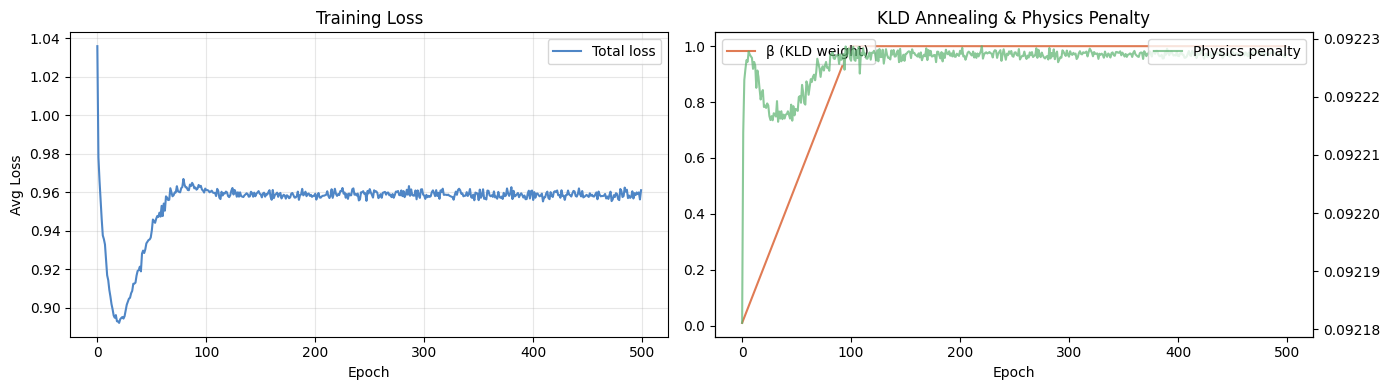

Saved training_loss.png


In [28]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history["loss"], lw=1.5, color="#4f86c6", label="Total loss")
ax1.set(xlabel="Epoch", ylabel="Avg Loss", title="Training Loss")
ax1.grid(alpha=0.3); ax1.legend()

ax2.plot(history["beta"], lw=1.5, color="#e07b54", label="β (KLD weight)")
ax2_r = ax2.twinx()
ax2_r.plot(history["phys"], lw=1.5, color="#5ab26e", alpha=0.7, label="Physics penalty")
ax2.set(xlabel="Epoch", title="KLD Annealing & Physics Penalty")
ax2.legend(loc="upper left"); ax2_r.legend(loc="upper right")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_loss.png"), dpi=150)
plt.show()
print("Saved training_loss.png")


## 10 · Generate Counterfactual Scenarios

In [29]:
model.eval()
results = {}

for name, spec in CFG.SCENARIOS.items():
    with torch.no_grad():
        z    = torch.randn(1, CFG.LATENT_DIM, device=device)
        cond = torch.tensor([spec["condition"]], dtype=torch.float32, device=device)
        out  = model.decode(z, cond)

        demand = out[:, :CFG.NUM_NODES, :].squeeze(0).permute(1, 0).cpu().numpy()
        results[name] = demand

    path = os.path.join(OUTPUT_DIR, f"{name}.npy")
    np.save(path, demand)
    zero_pct = (demand == 0).mean() * 100
    print(f"  [{name}]  shape={demand.shape}  "
          f"range=[{demand.min():.3f}, {demand.max():.3f}]  "
          f"zeros={zero_pct:.1f}%  → {path}")

print("\nAll scenarios generated ✓")
print("\n🎯  Health check — zeros should be < 30% after proper training:")
for n, d in results.items():
    z = (d == 0).mean() * 100
    status = "✅" if z < 30 else "⚠️ "
    print(f"   {status} {n:30s}  zeros={z:.1f}%")


  [extreme_winter_storm]  shape=(24, 32)  range=[0.000, 1.191]  zeros=63.7%  → /content/EVolvAI/output/extreme_winter_storm.npy
  [summer_peak]  shape=(24, 32)  range=[0.000, 1.168]  zeros=63.7%  → /content/EVolvAI/output/summer_peak.npy
  [full_electrification]  shape=(24, 32)  range=[0.000, 1.524]  zeros=63.7%  → /content/EVolvAI/output/full_electrification.npy
  [extreme_winter_v2]  shape=(24, 32)  range=[0.000, 1.029]  zeros=63.7%  → /content/EVolvAI/output/extreme_winter_v2.npy
  [rush_hour_gridlock]  shape=(24, 32)  range=[0.000, 1.219]  zeros=63.7%  → /content/EVolvAI/output/rush_hour_gridlock.npy

All scenarios generated ✓

🎯  Health check — zeros should be < 30% after proper training:
   ⚠️  extreme_winter_storm            zeros=63.7%
   ⚠️  summer_peak                     zeros=63.7%
   ⚠️  full_electrification            zeros=63.7%
   ⚠️  extreme_winter_v2               zeros=63.7%
   ⚠️  rush_hour_gridlock              zeros=63.7%


## 11 · Download All Outputs

In [30]:
zip_path = "/content/EVolvAI_output"
shutil.make_archive(zip_path, "zip", OUTPUT_DIR)
print(f"Archive: {zip_path}.zip")

try:
    from google.colab import files
    files.download(f"{zip_path}.zip")
except ImportError:
    print("Not in Colab — find outputs at:", OUTPUT_DIR)


Archive: /content/EVolvAI_output.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>